In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds

In [4]:
# Descargar set de datos de MNIST (Numeros escritos a mano y etiquetados)
data, metadata = tfds.load('mnist', as_supervised=True, with_info=True)

In [7]:
# Obtener en variables separadas los datos de entrenamiento (60k imágenes) y pruebas (10k imágenes)
train_dataset, test_dataset = data['train'], data['test']

In [10]:
# Normalizar los datos (Pasar valor de los pixeles de de 0-255 a 0-1)
def normalize(image: tf.Tensor, label: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
    image = tf.cast(image, tf.float32)
    image /= 255
    return image, label

train_dataset = train_dataset.map(normalize)
test_dataset = test_dataset.map(normalize)

# Agregar a cache (usar memoria para acelerar el entrenamiento)
train_dataset = train_dataset.cache()
test_dataset = test_dataset.cache()

In [13]:
# Clases o categorías de los números escritos a mano (0-9)
classes = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

In [ ]:
#Codigo para mostrar imagenes del set
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for i, (image, label) in enumerate(train_dataset.take(25)):
  image = image.numpy().reshape((28,28))
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(image, cmap=plt.cm.binary)
  plt.xlabel(classes[label])

plt.show()

In [17]:
# Crear el modelo de la red neuronal
# Modelo secuencial, capa de entrada Flatten (28x28 pixeles), capas ocultas Dense (50 neuronas, activación ReLU), capa de salida Dense (10 neuronas, activación softmax)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Flatten(), # Convertir la imagen de 28x28 pixeles a un vector de 784 pixeles
    tf.keras.layers.Dense(units=50, activation='relu'), # Capa oculta con 50 neuronas y activación ReLU
    tf.keras.layers.Dense(units=50, activation='relu'),
    tf.keras.layers.Dense(units=10, activation='softmax') # Capa de salida con 10 neuronas y activación softmax
])

In [19]:
# Compilar el modelo

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
train_dataset_size = metadata.splits['train'].num_examples
test_dataset_size = metadata.splits['test'].num_examples

In [26]:
LOTE = 32

# Preparar los datos para el entrenamiento y pruebas
train_dataset = data['train'].map(normalize).cache().repeat().shuffle(train_dataset_size).batch(LOTE)
test_dataset = data['test'].map(normalize).cache().batch(LOTE)

In [28]:
# Entrenar el modelo
import math

history = model.fit(
    train_dataset,
    epochs=60,
    steps_per_epoch=math.ceil(train_dataset_size / LOTE)
)

Epoch 1/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 352us/step - accuracy: 0.9971 - loss: 0.0105
Epoch 2/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 326us/step - accuracy: 0.9978 - loss: 0.0073
Epoch 3/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 331us/step - accuracy: 0.9988 - loss: 0.0039
Epoch 4/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 333us/step - accuracy: 0.9974 - loss: 0.0090
Epoch 5/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 348us/step - accuracy: 0.9977 - loss: 0.0087
Epoch 6/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 326us/step - accuracy: 0.9980 - loss: 0.0063
Epoch 7/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 329us/step - accuracy: 0.9981 - loss: 0.0066
Epoch 8/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 325us/step - accuracy: 0.9981 - loss: 0.0061
Epoch 9/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 325us/step - accuracy: 0.9979 - loss: 0.0069
Epoch 10/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 324us/step - accuracy: 0.9980 - loss: 0.0074
Epoch 11/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 325us/step - accuracy: 0.9979 - loss: 0.0074
Epoch 12

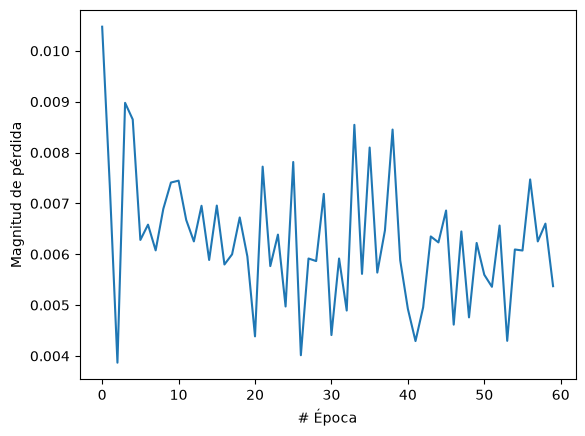

In [30]:
# Graficar resultados de la función de pérdida en cada epoca
plt.xlabel('# Época')
plt.ylabel('Magnitud de pérdida')
plt.plot(history.history['loss'])

W0000 00:00:1786209381.903720 2736508 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
W0000 00:00:1786209381.903774 2736508 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


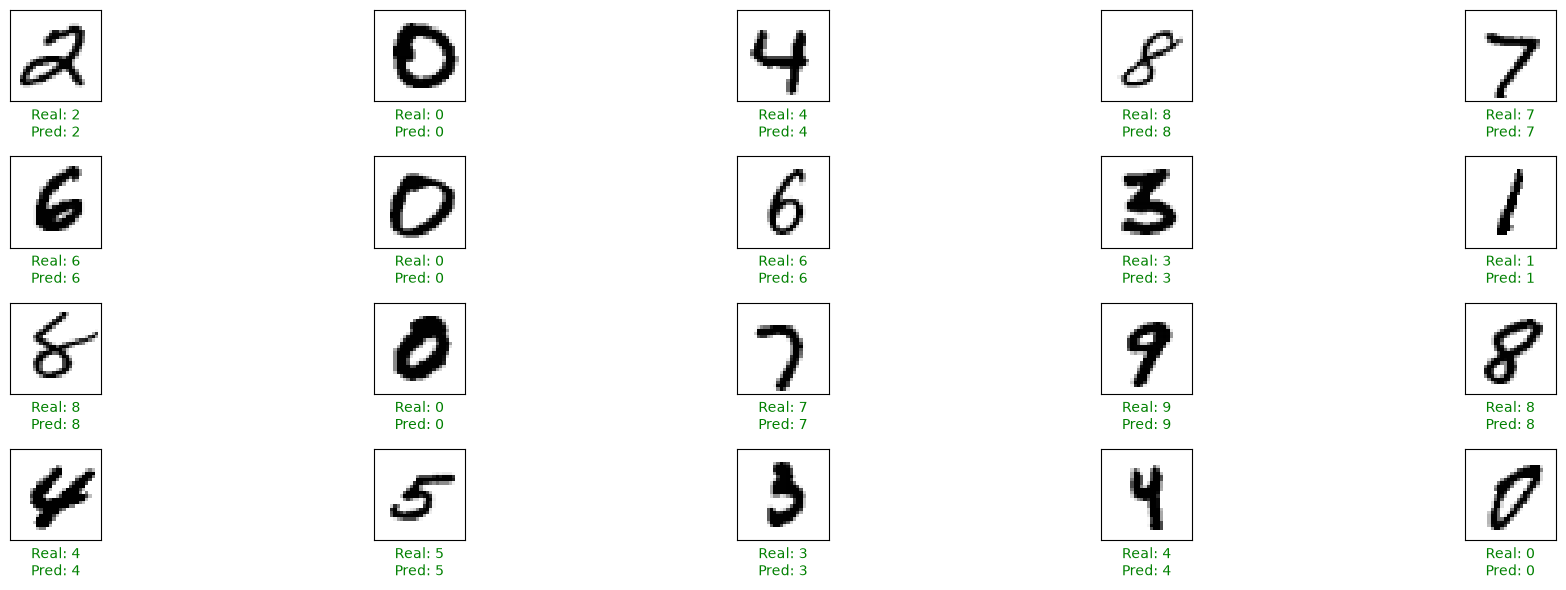

In [39]:
# Predecir 5 imágenes de prueba y graficar los resultados
for images, labels in test_dataset.take(1):
    images_20 = images[:20]
    labels_20 = labels[:20]

    predicts = model.predict(images_20, verbose=0)
    pred_labels = tf.argmax(predicts, axis=1)

    plt.figure(figsize=(20, 6))
    for j in range(20):
        plt.subplot(4, 5, j + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images_20[j].numpy().reshape(28, 28), cmap=plt.cm.binary)

        real = classes[int(labels_20[j].numpy())]
        pred = classes[int(pred_labels[j].numpy())]
        color = "green" if real == pred else "red"
        plt.xlabel(f"Real: {real}\nPred: {pred}", color=color)

    plt.tight_layout()
    plt.show()